<a href="https://colab.research.google.com/github/sampujya123/Energy-Consumption-Forecasting-System/blob/main/Sampujya_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('/content/Energy_production.csv')
data.head(10)

,index,Date,Region,Thermal Generation Actual (in MU),Thermal Generation Estimated (in MU),Nuclear Generation Actual (in MU),Nuclear Generation Estimated (in MU),Hydro Generation Actual (in MU),Hydro Generation Estimated (in MU),Total Actual Production
0,0,01-09-2017,Northern,624.23,484.21,30.36,35.57,273.27,320.81,927.86
1,1,01-09-2017,Western,1106.89,1024.33,25.17,3.81,72.00,21.53,1204.06
2,2,01-09-2017,Southern,576.66,578.55,62.73,49.80,111.57,64.78,750.96
3,3,01-09-2017,Eastern,441.02,429.39,NaN,NaN,85.94,69.36,526.96
4,4,01-09-2017,NorthEastern,29.11,15.91,NaN,NaN,24.64,21.21,53.75
5,5,02-09-2017,Northern,624.23,507.42,30.36,35.69,273.27,317.19,927.86
6,6,02-09-2017,Western,1106.89,1050.91,25.17,3.83,72.00,23.97,1204.06
7,7,02-09-2017,Southern,576.66,562.79,62.73,52.76,111.57,59.49,750.96
8,8,02-09-2017,Eastern,441.02,425.75,NaN,NaN,85.94,74.18,526.96
9,9,02-09-2017,NorthEastern,29.11,16.50,NaN,NaN,24.64,20.81,53.75


In [3]:
data.shape

(4945, 10)

In [4]:
print('Data from:',data['Date'].unique().min(),'to:',data['Date'].unique().max())

Data from: 01-01-2018 to: 31-12-2019


In [5]:
data['Region'].unique()

array(['Northern', 'Western', 'Southern', 'Eastern', 'NorthEastern'],
      dtype=object)

In [6]:
data.isnull().sum()

,0
index,0
Date,0
Region,0
Thermal Generation Actual (in MU),0
Thermal Generation Estimated (in MU),0
Nuclear Generation Actual (in MU),1978
Nuclear Generation Estimated (in MU),1978
Hydro Generation Actual (in MU),0
Hydro Generation Estimated (in MU),0
Total Actual Production,0


In [7]:
data.drop(columns=['index'],inplace=True)

In [8]:
data['Nuclear Generation Actual (in MU)'].mean()

np.float64(37.24220761712167)

In [9]:
null_values=data[data['Nuclear Generation Actual (in MU)'].isnull()]
null_values['Region'].unique()

array(['Eastern', 'NorthEastern'], dtype=object)

In [10]:
region_data=data.groupby('Region')
region_data.head(1)

,Date,Region,Thermal Generation Actual (in MU),Thermal Generation Estimated (in MU),Nuclear Generation Actual (in MU),Nuclear Generation Estimated (in MU),Hydro Generation Actual (in MU),Hydro Generation Estimated (in MU),Total Actual Production
0,01-09-2017,Northern,624.23,484.21,30.36,35.57,273.27,320.81,927.86
1,01-09-2017,Western,1106.89,1024.33,25.17,3.81,72.00,21.53,1204.06
2,01-09-2017,Southern,576.66,578.55,62.73,49.80,111.57,64.78,750.96
3,01-09-2017,Eastern,441.02,429.39,NaN,NaN,85.94,69.36,526.96
4,01-09-2017,NorthEastern,29.11,15.91,NaN,NaN,24.64,21.21,53.75


In [11]:
data.dtypes

,0
Date,object
Region,object
Thermal Generation Actual (in MU),float64
Thermal Generation Estimated (in MU),float64
Nuclear Generation Actual (in MU),float64
Nuclear Generation Estimated (in MU),float64
Hydro Generation Actual (in MU),float64
Hydro Generation Estimated (in MU),float64
Total Actual Production,float64


In [12]:
# data['Thermal Generation Actual (in MU)']=data['Thermal Generation Actual (in MU)'].str.replace(',', '').astype(float)
# data['Thermal Generation Estimated (in MU)']=data['Thermal Generation Estimated (in MU)'].str.replace(',', '').astype(float)

In [13]:
data['Date']=pd.to_datetime(data['Date'],format='mixed')

In [14]:
data.dtypes

,0
Date,datetime64[ns]
Region,object
Thermal Generation Actual (in MU),float64
Thermal Generation Estimated (in MU),float64
Nuclear Generation Actual (in MU),float64
Nuclear Generation Estimated (in MU),float64
Hydro Generation Actual (in MU),float64
Hydro Generation Estimated (in MU),float64
Total Actual Production,float64


In [15]:
data.loc[data['Region'].isin( ['Eastern','NorthEastern']),'Nuclear Generation Actual (in MU)']=0

In [16]:
data.loc[data['Region'].isin( ['Eastern','NorthEastern']),'Nuclear Generation Estimated (in MU)']=0

In [17]:
data['Month']=data['Date'].dt.month
data['Day']=data['Date'].dt.day
data['Year'] = data['Date'].dt.year
data['Dayofweek'] = data['Date'].dt.dayofweek

In [18]:
data.head(10)

,Date,Region,Thermal Generation Actual (in MU),Thermal Generation Estimated (in MU),Nuclear Generation Actual (in MU),Nuclear Generation Estimated (in MU),Hydro Generation Actual (in MU),Hydro Generation Estimated (in MU),Total Actual Production,Month,Day,Year,Dayofweek
0,2017-01-09,Northern,624.23,484.21,30.36,35.57,273.27,320.81,927.86,1,9,2017,0
1,2017-01-09,Western,1106.89,1024.33,25.17,3.81,72.00,21.53,1204.06,1,9,2017,0
2,2017-01-09,Southern,576.66,578.55,62.73,49.80,111.57,64.78,750.96,1,9,2017,0
3,2017-01-09,Eastern,441.02,429.39,0.00,0.00,85.94,69.36,526.96,1,9,2017,0
4,2017-01-09,NorthEastern,29.11,15.91,0.00,0.00,24.64,21.21,53.75,1,9,2017,0
5,2017-02-09,Northern,624.23,507.42,30.36,35.69,273.27,317.19,927.86,2,9,2017,3
6,2017-02-09,Western,1106.89,1050.91,25.17,3.83,72.00,23.97,1204.06,2,9,2017,3
7,2017-02-09,Southern,576.66,562.79,62.73,52.76,111.57,59.49,750.96,2,9,2017,3
8,2017-02-09,Eastern,441.02,425.75,0.00,0.00,85.94,74.18,526.96,2,9,2017,3
9,2017-02-09,NorthEastern,29.11,16.50,0.00,0.00,24.64,20.81,53.75,2,9,2017,3


In [19]:
total_energy_northern=data.loc[data['Region']=='Northern', ['Thermal Generation Actual (in MU)','Nuclear Generation Actual (in MU)','Hydro Generation Actual (in MU)']].sum()
total_energy_northern

,0
Thermal Generation Actual (in MU),655048.26
Nuclear Generation Actual (in MU),26964.08
Hydro Generation Actual (in MU),188854.16


In [20]:
total_energy_southern=data.loc[data['Region']=='Southern', ['Thermal Generation Actual (in MU)','Nuclear Generation Actual (in MU)','Hydro Generation Actual (in MU)']].sum()
total_energy_southern

,0
Thermal Generation Actual (in MU),610753.56
Nuclear Generation Actual (in MU),55855.21
Hydro Generation Actual (in MU),71109.34


In [21]:
total_energy_eastern=data.loc[data['Region']=='Eastern', ['Thermal Generation Actual (in MU)','Nuclear Generation Actual (in MU)','Hydro Generation Actual (in MU)']].sum()
total_energy_eastern

,0
Thermal Generation Actual (in MU),482123.72
Nuclear Generation Actual (in MU),0.00
Hydro Generation Actual (in MU),48686.62


In [22]:
total_energy_western=data.loc[data['Region']=='Western', ['Thermal Generation Actual (in MU)','Nuclear Generation Actual (in MU)','Hydro Generation Actual (in MU)']].sum()
total_energy_western

,0
Thermal Generation Actual (in MU),1206631.65
Nuclear Generation Actual (in MU),27678.34
Hydro Generation Actual (in MU),36235.34


In [23]:
total_energy_NorthEastern=data.loc[data['Region']=='NorthEastern', ['Thermal Generation Actual (in MU)','Nuclear Generation Actual (in MU)','Hydro Generation Actual (in MU)']].sum()
total_energy_NorthEastern

,0
Thermal Generation Actual (in MU),32115.79
Nuclear Generation Actual (in MU),0.00
Hydro Generation Actual (in MU),17612.32


In [24]:
import matplotlib.pyplot as plt

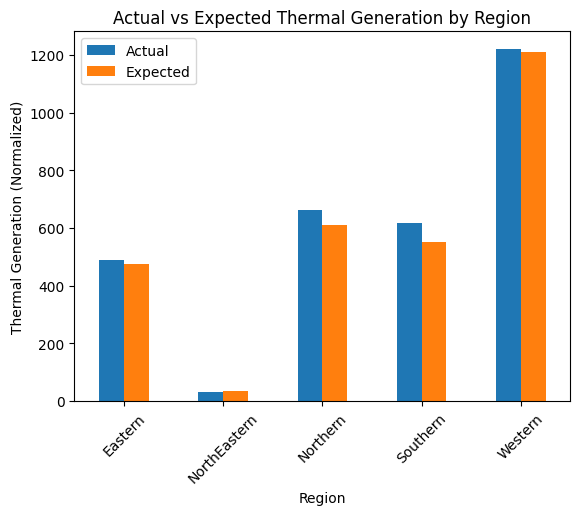

In [25]:
thermal_generation=data.groupby('Region')[['Thermal Generation Actual (in MU)', 'Thermal Generation Estimated (in MU)']].mean()
thermal_generation.plot(kind='bar')
plt.title('Actual vs Expected Thermal Generation by Region')
plt.xlabel('Region')
plt.ylabel('Thermal Generation (Normalized)')
plt.xticks(rotation=45)
plt.legend(['Actual', 'Expected'])
plt.show()

In [26]:
thermal_data=data[['Date','Region', 'Thermal Generation Actual (in MU)', 'Thermal Generation Estimated (in MU)']]
nuclear_data=data[['Date','Region', 'Nuclear Generation Actual (in MU)', 'Nuclear Generation Estimated (in MU)']]
hydro_data=data[['Date','Region', 'Hydro Generation Actual (in MU)', 'Hydro Generation Estimated (in MU)']]

thermal_data['Date'] = pd.to_datetime(
    thermal_data['Date']
)

thermal_data = thermal_data.sort_values('Date')

thermal_data.set_index('Date', inplace=True)

print("Thermal Generation Data:")
thermal_data.head()

Thermal Generation Data:


/tmp/ipykernel_5704/1341813809.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thermal_data['Date'] = pd.to_datetime(


,Region,Thermal Generation Actual (in MU),Thermal Generation Estimated (in MU)
Date,,,
2017-01-09,Northern,624.23,484.21
2017-01-09,Western,1106.89,1024.33
2017-01-09,Southern,576.66,578.55
2017-01-09,Eastern,441.02,429.39
2017-01-09,NorthEastern,29.11,15.91


In [27]:
print("\nNuclear Generation Data:")
nuclear_data.head()


Nuclear Generation Data:


,Date,Region,Nuclear Generation Actual (in MU),Nuclear Generation Estimated (in MU)
0,2017-01-09,Northern,30.36,35.57
1,2017-01-09,Western,25.17,3.81
2,2017-01-09,Southern,62.73,49.80
3,2017-01-09,Eastern,0.00,0.00
4,2017-01-09,NorthEastern,0.00,0.00


In [28]:
print("\nHydro Generation Data:")
hydro_data.head()


Hydro Generation Data:


,Date,Region,Hydro Generation Actual (in MU),Hydro Generation Estimated (in MU)
0,2017-01-09,Northern,273.27,320.81
1,2017-01-09,Western,72.00,21.53
2,2017-01-09,Southern,111.57,64.78
3,2017-01-09,Eastern,85.94,69.36
4,2017-01-09,NorthEastern,24.64,21.21


In [29]:
thermal_data.columns = thermal_data.columns.str.strip()

In [30]:
df_pivoted = thermal_data.pivot_table(
    index=thermal_data.index,
    columns='Region',
    values='Thermal Generation Actual (in MU)'
)

In [31]:
df_pivoted = df_pivoted.interpolate(method='linear')

df_pivoted = df_pivoted.asfreq('D')

df_pivoted = df_pivoted.ffill().bfill()

In [32]:
target_region = 'Northern'

series = df_pivoted[target_region]

In [33]:
train_size = int(len(series) * 0.8)

train = series.iloc[:train_size]

test = series.iloc[train_size:]

In [34]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.2 MB/s eta 0:00:00


In [35]:
# from pmdarima import auto_arima

# auto_model = auto_arima(
#     train,
#     seasonal=True,
#     m=7,              # weekly seasonality for daily data
#     trace=True,
#     suppress_warnings=True,
#     stepwise=True
# )

# print(auto_model.summary())

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Fit final model
model = SARIMAX(
    train,
    order=(2,0,2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

In [37]:
forecast = results.get_forecast(
    steps=len(test)
)

predictions = forecast.predicted_mean

In [39]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

mse = mean_squared_error(
    test,
    predictions
)

mae = mean_absolute_error(
    test,
    predictions
)


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

MSE: 314.6095
MAE: 10.8815


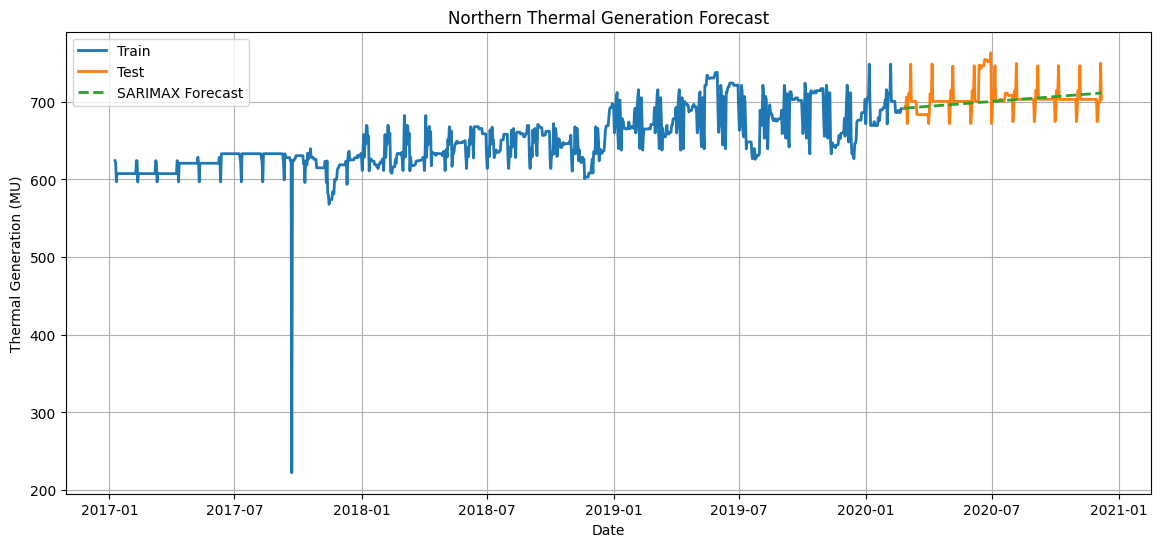

In [40]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label='Train',
    linewidth=2
)

plt.plot(
    test.index,
    test,
    label='Test',
    linewidth=2
)

plt.plot(
    test.index,
    predictions,
    label='SARIMAX Forecast',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Date')

plt.ylabel('Thermal Generation (MU)')

plt.title(
    f'{target_region} Thermal Generation Forecast'
)

plt.legend()

plt.grid(True)

plt.show()

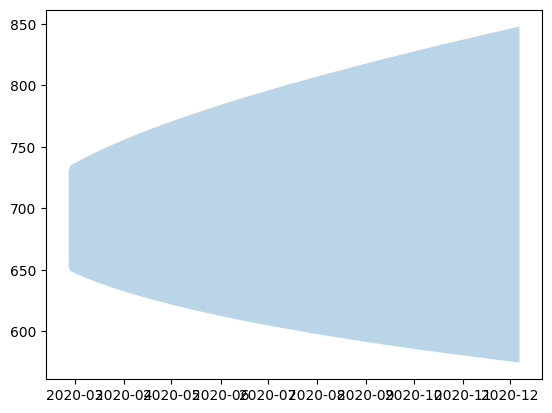

In [41]:
conf_int = forecast.conf_int()

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

In [42]:
# Save dataframe as CSV

data.to_csv(
    'processsed_data.csv',
    index=False
)

print("CSV file saved successfully!")

CSV file saved successfully!


Consumption data set

In [43]:
df=pd.read_csv('/content/dataset_tk.csv')

In [44]:
print(df.dtypes)
print('Shape:',df.shape)

Unnamed: 0            object
Punjab               float64
Haryana              float64
Rajasthan            float64
Delhi                float64
UP                   float64
Uttarakhand          float64
HP                   float64
J&K                  float64
Chandigarh           float64
Chhattisgarh         float64
Gujarat              float64
MP                   float64
Maharashtra          float64
Goa                  float64
DNH                  float64
Andhra Pradesh       float64
Telangana            float64
Karnataka            float64
Kerala               float64
Tamil Nadu           float64
Pondy                float64
Bihar                float64
Jharkhand            float64
Odisha               float64
West Bengal          float64
Sikkim               float64
Arunachal Pradesh    float64
Assam                float64
Manipur              float64
Meghalaya            float64
Mizoram              float64
Nagaland             float64
Tripura              float64
dtype: object


In [45]:
df.head()

,Unnamed: 0,Punjab,Haryana,Rajasthan,Delhi,UP,Uttarakhand,HP,J&K,Chandigarh,...,Odisha,West Bengal,Sikkim,Arunachal Pradesh,Assam,Manipur,Meghalaya,Mizoram,Nagaland,Tripura
0,02/01/2019 00:00:00,119.9,130.3,234.1,85.8,313.9,40.7,30.0,52.5,5.0,...,70.2,108.2,2.0,2.1,21.7,2.7,6.1,1.9,2.2,3.4
1,03/01/2019 00:00:00,121.9,133.5,240.2,85.5,311.8,39.3,30.1,54.1,4.9,...,67.9,110.2,1.9,2.2,23.4,2.4,6.5,1.8,2.2,3.6
2,04/01/2019 00:00:00,118.8,128.2,239.8,83.5,320.7,38.1,30.1,53.2,4.8,...,66.3,106.8,1.7,2.2,21.7,2.4,6.3,1.7,2.2,3.5
3,05/01/2019 00:00:00,121.0,127.5,239.1,79.2,299.0,39.2,30.2,51.5,4.3,...,65.8,107.0,2.0,2.2,22.5,2.7,5.7,1.8,2.3,3.5
4,06/01/2019 00:00:00,121.4,132.6,240.4,76.6,286.8,39.2,31.0,53.2,4.3,...,62.9,106.4,2.0,2.2,21.7,2.7,6.2,1.9,2.3,3.3


In [46]:
df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

In [47]:
df['Date']=pd.to_datetime(df['Date'], format="mixed")
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day

In [48]:
df.tail(3)

,Date,Punjab,Haryana,Rajasthan,Delhi,UP,Uttarakhand,HP,J&K,Chandigarh,...,Sikkim,Arunachal Pradesh,Assam,Manipur,Meghalaya,Mizoram,Nagaland,Tripura,Month,Day
500,2020-03-12,132.1,129.7,205.6,85.6,336.7,37.8,26.2,45.2,4.0,...,1.4,2.1,21.7,2.3,5.4,1.5,2.0,3.6,3,12
501,2020-04-12,132.1,128.4,207.0,83.9,334.6,38.2,27.0,43.0,4.0,...,1.2,2.0,24.2,2.5,5.7,1.6,2.0,3.3,4,12
502,2020-05-12,120.4,111.2,201.4,83.6,287.3,35.2,24.3,42.6,3.5,...,1.2,2.1,20.3,2.5,5.8,1.6,2.1,3.3,5,12


In [49]:
print(df['Date'].min(),df['Date'].max())

2019-01-07 00:00:00 2020-05-23 00:00:00


In [50]:
df.isnull().sum()

,0
Date,0
Punjab,0
Haryana,0
Rajasthan,0
Delhi,0
UP,0
Uttarakhand,0
HP,0
J&K,0
Chandigarh,0


In [51]:
# Save dataframe as CSV

df.to_csv(
    'processsed_data_state_con.csv',
    index=False
)

print("CSV file saved successfully!")

CSV file saved successfully!


In [52]:
#from sklearn.preprocessing import MinMaxScaler
#numerical_columns=['Punjab', 'Haryana','Rajasthan','Delhi',
#'UP','Uttarakhand','HP','J&K','Chandigarh','Chhattisgarh','Gujarat','MP','Maharashtra','Goa','DNH','Andhra Pradesh','Telangana',
#'Karnataka','Kerala', 'Tamil Nadu', 'Pondy','Bihar','Jharkhand','Odisha','West Bengal','Sikkim','Arunachal Pradesh',
#'Assam','Manipur','Meghalaya', 'Mizoram', 'Nagaland','Tripura'   ]
# Initialize MinMaxScaler
#scaler=MinMaxScaler()
#df[numerical_columns]=scaler.fit_transform(df[numerical_columns])
#print(df.head)

In [53]:
Telangana=pd.DataFrame(data=df,columns=['Telangana','Date','Month','Day'])
Telangana.set_index('Date',inplace=True)
Telangana.sort_values(by='Date')
Telangana.head()

,Telangana,Month,Day
Date,,,
2019-02-01,204.2,2,1
2019-03-01,204.5,3,1
2019-04-01,201.2,4,1
2019-05-01,201.7,5,1
2019-06-01,194.9,6,1


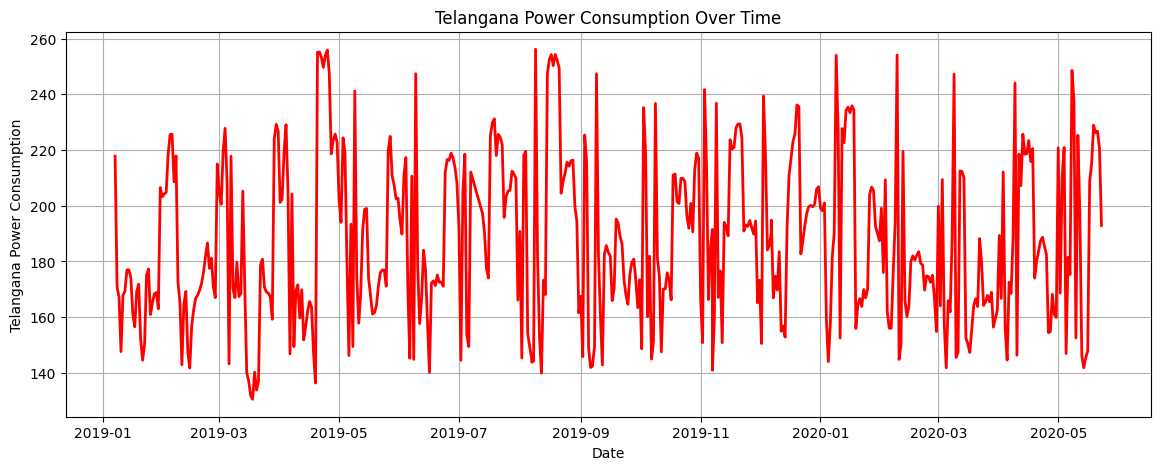

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
Telangana.index = pd.to_datetime(Telangana.index)

# Sort dates
Telangana = Telangana.sort_index()

# Plot
plt.figure(figsize=(14,5))

plt.plot(
    Telangana.index,
    Telangana['Telangana'],
    color='red',
    linewidth=2
)

plt.xlabel('Date')
plt.ylabel('Telangana Power Consumption')

plt.title('Telangana Power Consumption Over Time')

plt.grid(True)

plt.show()

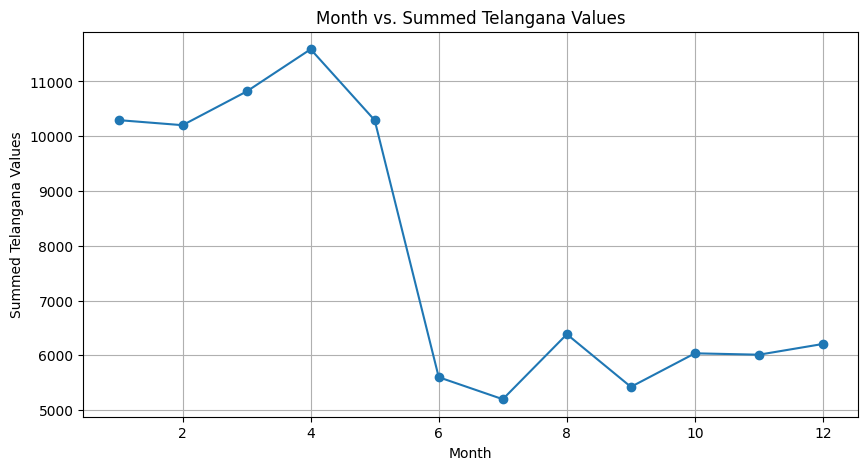

In [55]:
monthly_data = df.groupby('Month')['Telangana'].sum().reset_index()

# Plotting Month vs. Summed Telangana values
plt.figure(figsize=(10, 5))
plt.plot(monthly_data['Month'], monthly_data['Telangana'], marker='o')
plt.xlabel('Month')
plt.ylabel('Summed Telangana Values')
plt.title('Month vs. Summed Telangana Values')
plt.grid(True)
plt.show()

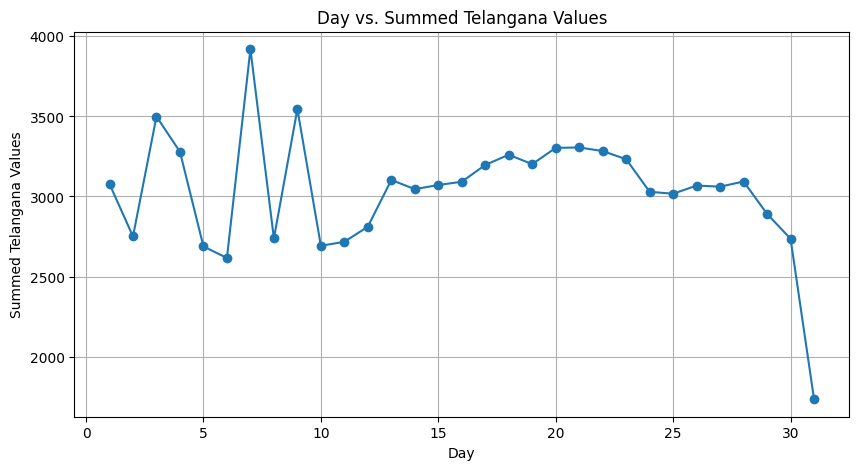

In [56]:
daily_data = df.groupby('Day')['Telangana'].sum().reset_index()

# Plotting Month vs. Summed Telangana values
plt.figure(figsize=(10, 5))
plt.plot(daily_data['Day'], daily_data['Telangana'], marker='o')
plt.xlabel('Day')
plt.ylabel('Summed Telangana Values')
plt.title('Day vs. Summed Telangana Values')
plt.grid(True)
plt.show()

In [57]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# metrics_df=pd.DataFrame(metrics)
# metrics_df.set_index('State', inplace=True)
# plt.figure(figsize=(12, 8))
# sns.heatmap(metrics_df[['MAE']].sort_values(by=['MAE'], ascending=False), annot=True, cmap='viridis', fmt='.2f')
# plt.title('Heat Map of Mean Absolute Error for Each State')
# plt.show()

In [58]:
print(Telangana.index.duplicated().sum())

5


In [59]:
Telangana = Telangana.groupby(Telangana.index).mean()

Test Mean Squared Error: 872.0305838758493


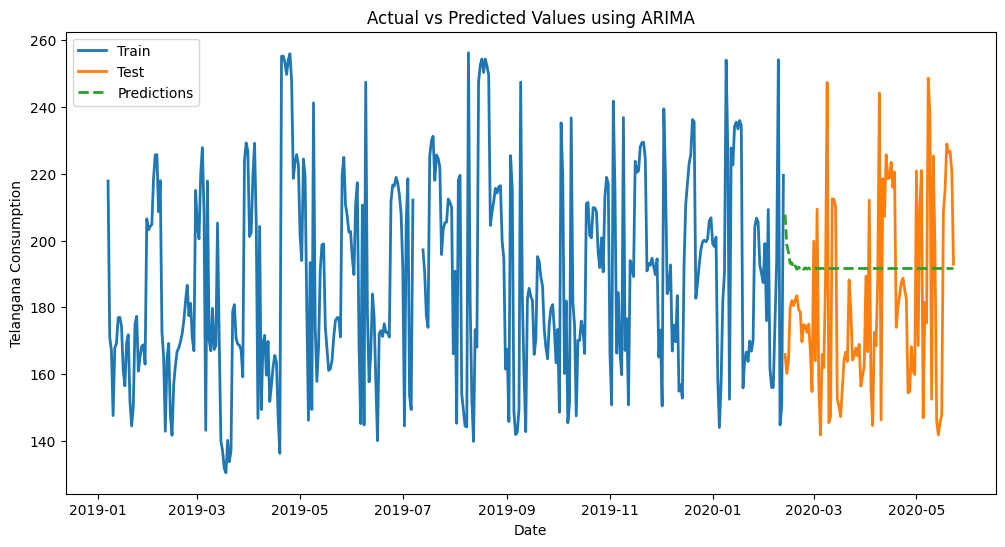

In [60]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
Telangana.index = pd.to_datetime(Telangana.index)

# Sort by date
Telangana = Telangana.sort_index()
Telangana = Telangana.resample('D').mean()

# Train-test split
train_size = int(len(Telangana) * 0.8)

train = Telangana.iloc[:train_size]
test = Telangana.iloc[train_size:]

# Fit ARIMA model
model = ARIMA(
    train['Telangana'],
    order=(2,1,2)
)

model_fit = model.fit()

# Forecast
predictions = model_fit.forecast(steps=len(test))

# MSE
test_mse = mean_squared_error(
    test['Telangana'],
    predictions
)

print(f"Test Mean Squared Error: {test_mse}")

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Telangana'],
    label='Train',
    linewidth=2
)

plt.plot(
    test.index,
    test['Telangana'],
    label='Test',
    linewidth=2
)

plt.plot(
    test.index,
    predictions,
    label='Predictions',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Date')
plt.ylabel('Telangana Consumption')

plt.title('Actual vs Predicted Values using ARIMA')

plt.legend()

plt.show()

SARIMA Mean Squared Error: 809.0503864050976


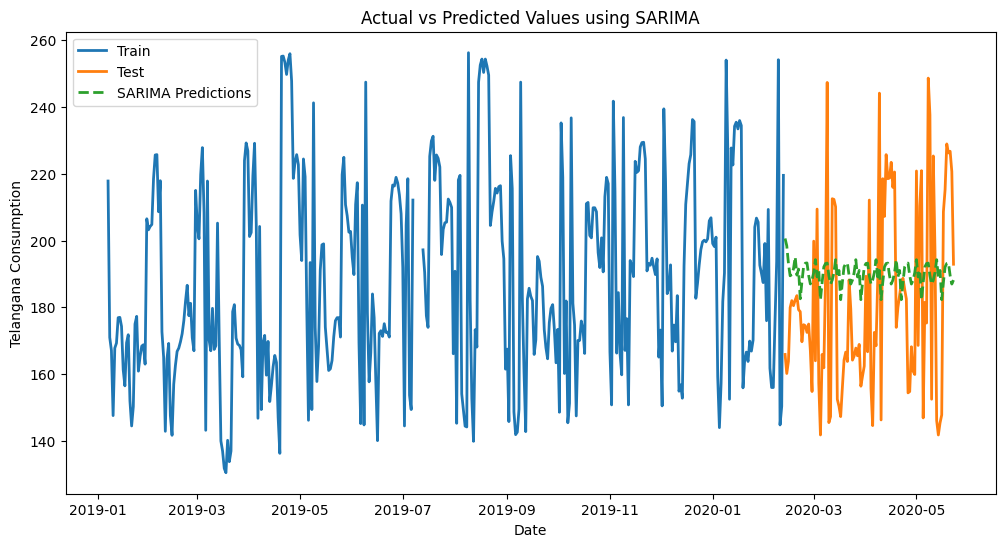

In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Ensure datetime index
Telangana.index = pd.to_datetime(Telangana.index)

# Sort by date
Telangana = Telangana.sort_index()
Telangana = Telangana.resample('D').mean()

# Train-test split
train_size_tel = int(len(Telangana) * 0.8)

train_tel = Telangana.iloc[:train_size_tel]
test_tel = Telangana.iloc[train_size_tel:]

# Build SARIMA model
sarima_model_tel = SARIMAX(
    train_tel['Telangana'],
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit_tel = sarima_model_tel.fit(disp=False)

# Forecast
sarima_predictions_tel = sarima_fit_tel.forecast(steps=len(test_tel))

# MSE
sarima_mse_tel = mean_squared_error(
    test_tel['Telangana'],
    sarima_predictions_tel
)

print(f"SARIMA Mean Squared Error: {sarima_mse_tel}")

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    train_tel.index,
    train_tel['Telangana'],
    label='Train',
    linewidth=2
)

plt.plot(
    test_tel.index,
    test_tel['Telangana'],
    label='Test',
    linewidth=2
)

plt.plot(
    test_tel.index,
    sarima_predictions_tel,
    label='SARIMA Predictions',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Date')
plt.ylabel('Telangana Consumption')
plt.title('Actual vs Predicted Values using SARIMA')

plt.legend()

plt.show()

In [62]:
# from itertools import product
# import warnings
# warnings.filterwarnings("ignore")
# p = range(0, 4)
# d = range(0, 2)
# q = range(0, 2)
# P = range(0, 2)
# D = range(0, 2)
# Q = range(0, 2)
# s = [12]  # Season length

# # Generate all different combinations of p, d, q and seasonal p, d, q
# parameters = list(product(p, d, q))
# seasonal_parameters = list(product(P, D, Q, s))

# # Function to fit and predict using SARIMA model
# def fit_predict_sarima(state_data, state_name):
#     train_size = int(len(state_data) * 0.8)
#     train, test = state_data.iloc[:train_size], state_data.iloc[train_size:]

#     results = []

#     for param in parameters:
#         for seasonal_param in seasonal_parameters:
#             try:
#                 model = SARIMAX(train[state_name],
#                                 order=param,
#                                 seasonal_order=seasonal_param,
#                                 enforce_stationarity=False,
#                                 enforce_invertibility=False)
#                 result = model.fit(disp=False)

#                 # Forecast
#                 predictions = result.predict(start=len(train), end=len(state_data) - 1, dynamic=False)

#                 # Calculate mean squared error
#                 mse = mean_squared_error(test[state_name], predictions)
#                 results.append((param, seasonal_param, mse))

#                 print(f"SARIMA{param}x{seasonal_param} - MSE: {mse}")

#             except Exception as e:
#                 print(f"SARIMA{param}x{seasonal_param} - Exception: {e}")
#                 continue

#     return results

# # Example state data (replace 'Telangana' with the actual state name)
# results = fit_predict_sarima(df, 'Telangana')

# # Sort results by MSE
# results = sorted(results, key=lambda x: x[2])

# # Display the best result
# print(f"\nBest SARIMA parameters: {results[0][0]}x{results[0][1]} - MSE: {results[0][2]}")

In [63]:
pip install prophet

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

In [65]:
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Create Prophet dataframe
prophet_df = df[['Date', 'Telangana']].rename(
    columns={
        'Date':'ds',
        'Telangana':'y'
    }
)

# Remove missing values
prophet_df = prophet_df.dropna()

In [66]:
prophet_df.head()

,ds,y
175,2019-01-07,217.8
211,2019-01-08,171.0
241,2019-01-09,167.1
270,2019-01-10,147.6
300,2019-01-11,167.8


In [67]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]

test = prophet_df.iloc[train_size:]

In [68]:
q1 = prophet_df['y'].quantile(0.25)
q3 = prophet_df['y'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

prophet_df = prophet_df[
    (prophet_df['y'] >= lower) &
    (prophet_df['y'] <= upper)
]

In [69]:
model = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    n_changepoints=50
)

# Monthly seasonality
model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# Train model
model.fit(train)

In [70]:
future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

In [71]:
forecast = model.predict(future)

# Merge predictions with test set
test_forecast = test.merge(
    forecast[['ds', 'yhat']],
    on='ds',
    how='left'
)

# Metrics
mse = mean_squared_error(
    test_forecast['y'],
    test_forecast['yhat']
)

mae = mean_absolute_error(
    test_forecast['y'],
    test_forecast['yhat']
)

In [72]:
print(f"MSE : {mse:.4f}")

print(f"MAE : {mae:.4f}")

MSE : 1319.1268
MAE : 31.1215


In [73]:
train = train.sort_values('ds')

test = test.sort_values('ds')

forecast = forecast.sort_values('ds')

# Forecast only for test period
forecast_filtered = forecast[
    forecast['ds'] >= test['ds'].min()
]

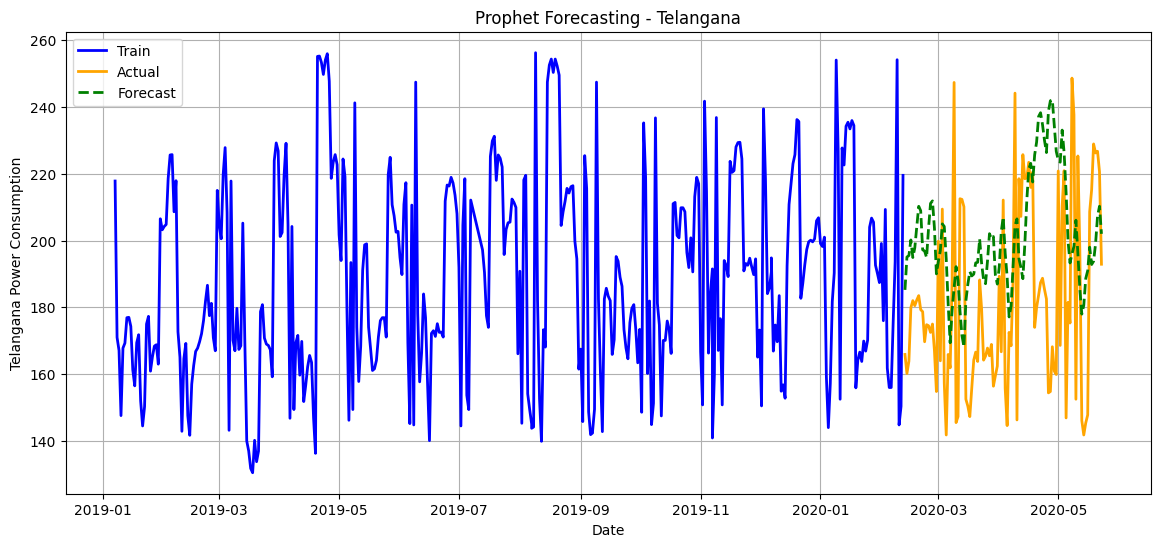

In [74]:
plt.figure(figsize=(14,6))

# Train data
plt.plot(
    train['ds'],
    train['y'],
    label='Train',
    color='blue',
    linewidth=2
)

# Test data
plt.plot(
    test['ds'],
    test['y'],
    label='Actual',
    color='orange',
    linewidth=2
)

# Predictions
plt.plot(
    forecast_filtered['ds'],
    forecast_filtered['yhat'],
    label='Forecast',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Date')

plt.ylabel('Telangana Power Consumption')

plt.title(
    'Prophet Forecasting - Telangana'
)

plt.legend()

plt.grid(True)

plt.show()

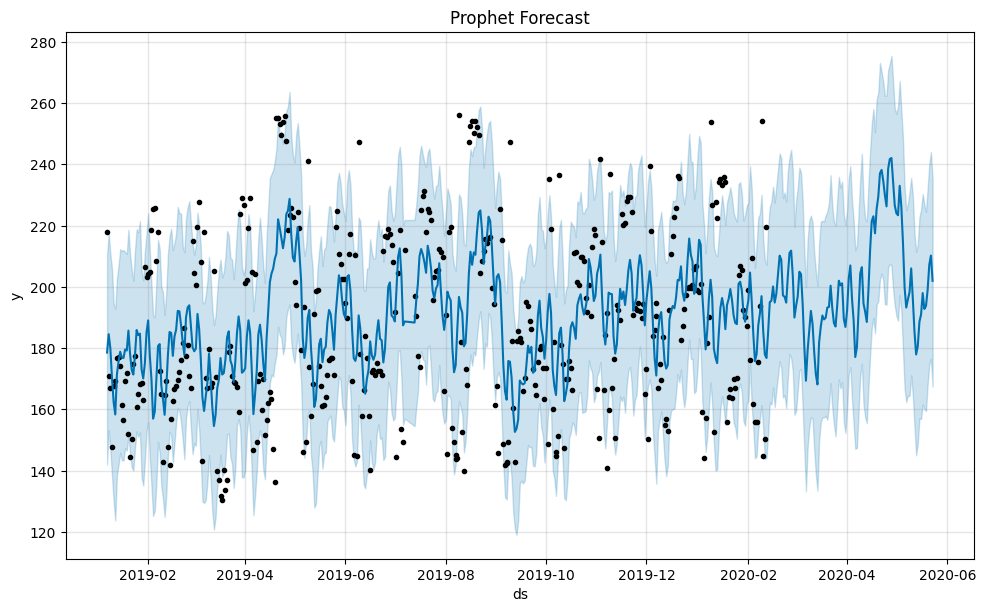

In [75]:
fig1 = model.plot(forecast)

plt.title('Prophet Forecast')

plt.show()

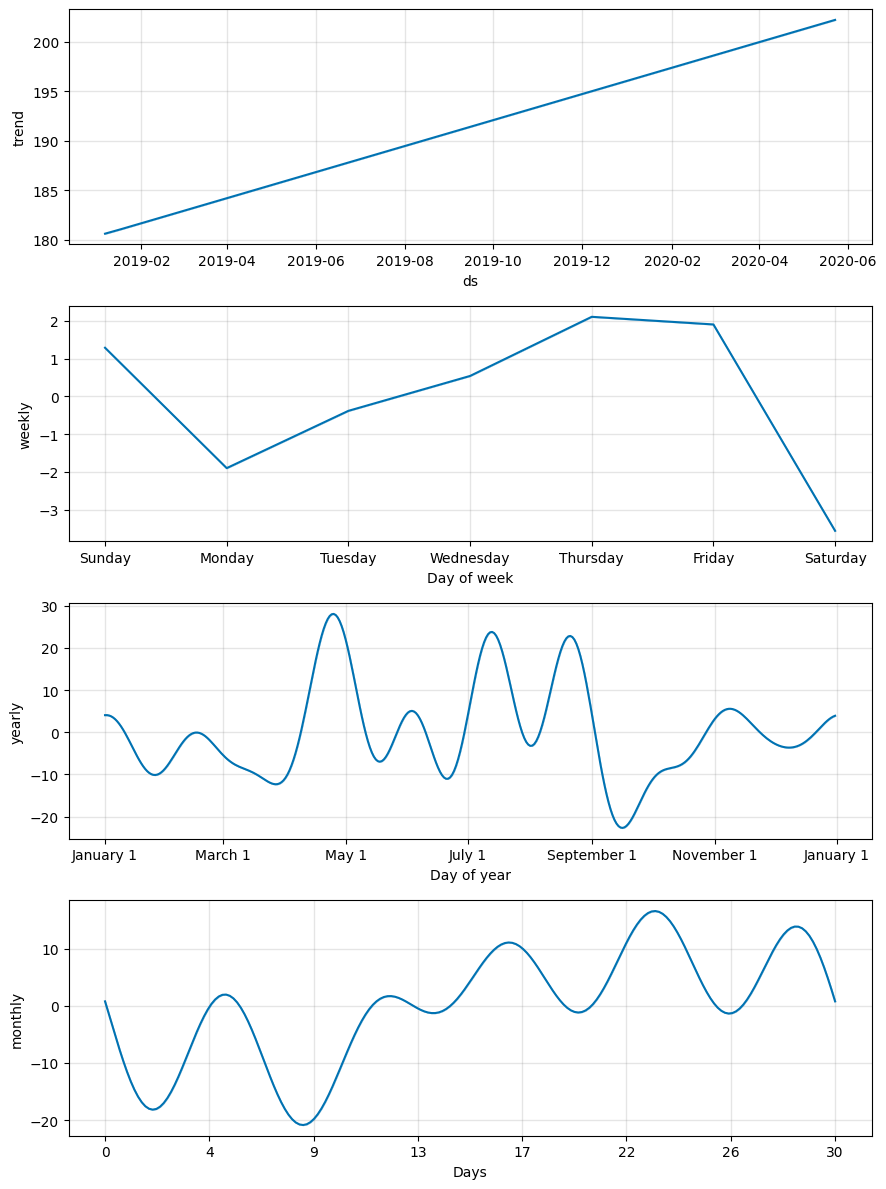

In [76]:
fig2 = model.plot_components(forecast)

plt.show()

In [77]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.1 MB/s eta 0:00:00


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from ipywidgets import interact, widgets

# DATA PREPARATION

# Convert datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort data
df = df.sort_values('Date')

# MODEL EVALUATION FUNCTION

def evaluate_models(state_data, state_name):

    ts_df = state_data[['Date', state_name]].copy()

    ts_df = ts_df.rename(
        columns={
            'Date':'ds',
            state_name:'y'
        }
    )

    ts_df = ts_df.dropna()

    ts_df = ts_df.sort_values('ds')

    # Set datetime index
    ts_df.set_index('ds', inplace=True)

    # SORT INDEX
    ts_df = ts_df.sort_index()

    # REMOVE DUPLICATE DATES
    ts_df = ts_df.groupby(ts_df.index).mean()

    # APPLY DAILY FREQUENCY
    ts_df = ts_df.asfreq('D')

    # Fill missing values
    ts_df['y'] = ts_df['y'].interpolate()

    train_size = int(len(ts_df) * 0.8)

    train = ts_df.iloc[:train_size]

    test = ts_df.iloc[train_size:]

    results = []

    # ========================================================
    # ---------------- ARIMA ----------------
    # ========================================================

    try:

        arima_model = ARIMA(
            train['y'],
            order=(1,0,1)
        )

        arima_fit = arima_model.fit()

        arima_pred = arima_fit.forecast(
            steps=len(test)
        )

        arima_mse = mean_squared_error(
            test['y'],
            arima_pred
        )

        arima_rmse = np.sqrt(arima_mse)

        arima_mae = mean_absolute_error(
            test['y'],
            arima_pred
        )

        results.append({
            'Model':'ARIMA',
            'MSE':arima_mse,
            'RMSE':arima_rmse,
            'MAE':arima_mae
        })

    except Exception as e:

        print(f"ARIMA Error : {e}")

    # ========================================================
    # ---------------- SARIMA ----------------
    # ========================================================

    try:

        sarima_model = SARIMAX(
            train['y'],
            order=(1,0,1),
            seasonal_order=(1,1,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        sarima_fit = sarima_model.fit(
            disp=False
        )

        sarima_pred = sarima_fit.forecast(
            steps=len(test)
        )

        sarima_mse = mean_squared_error(
            test['y'],
            sarima_pred
        )

        sarima_rmse = np.sqrt(sarima_mse)

        sarima_mae = mean_absolute_error(
            test['y'],
            sarima_pred
        )

        results.append({
            'Model':'SARIMA',
            'MSE':sarima_mse,
            'RMSE':sarima_rmse,
            'MAE':sarima_mae
        })

    except Exception as e:

        print(f"SARIMA Error : {e}")

    # ========================================================
    # ---------------- PROPHET ----------------
    # ========================================================

    try:

        prophet_train = train.reset_index()

        prophet_test = test.reset_index()

        prophet_model = Prophet(
            seasonality_mode='additive',
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.5,
            n_changepoints=50
        )

        # Add monthly seasonality
        prophet_model.add_seasonality(
            name='monthly',
            period=30.5,
            fourier_order=5
        )

        prophet_model.fit(
            prophet_train
        )

        future = prophet_model.make_future_dataframe(
            periods=len(prophet_test),
            freq='D'
        )

        forecast = prophet_model.predict(
            future
        )

        # Proper merge alignment
        prophet_forecast = prophet_test.merge(
            forecast[['ds','yhat']],
            on='ds',
            how='left'
        )

        prophet_mse = mean_squared_error(
            prophet_forecast['y'],
            prophet_forecast['yhat']
        )

        prophet_rmse = np.sqrt(
            prophet_mse
        )

        prophet_mae = mean_absolute_error(
            prophet_forecast['y'],
            prophet_forecast['yhat']
        )

        results.append({
            'Model':'Prophet',
            'MSE':prophet_mse,
            'RMSE':prophet_rmse,
            'MAE':prophet_mae
        })

    except Exception as e:

        print(f"Prophet Error : {e}")

    # ========================================================
    # COMPARISON TABLE
    # ========================================================

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='RMSE'
    )

    print("\nMODEL COMPARISON\n")

    print(results_df)

    # ========================================================
    # BEST MODEL
    # ========================================================

    best_model = results_df.iloc[0]['Model']

    print(f"\nBEST MODEL : {best_model}")

    # ========================================================
    # FINAL FORECAST USING BEST MODEL
    # ========================================================

    full_series = ts_df['y']

    if best_model == 'ARIMA':

        final_model = ARIMA(
            full_series,
            order=(1,0,1)
        ).fit()

        forecast_values = final_model.forecast(
            steps=30
        )

        future_dates = pd.date_range(
            start=ts_df.index.max(),
            periods=31,
            freq='D'
        )[1:]

    elif best_model == 'SARIMA':

        final_model = SARIMAX(
            full_series,
            order=(1,0,1),
            seasonal_order=(1,1,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast_values = final_model.forecast(
            steps=30
        )

        future_dates = pd.date_range(
            start=ts_df.index.max(),
            periods=31,
            freq='D'
        )[1:]

    else:

        prophet_full = ts_df.reset_index()

        final_model = Prophet(
            seasonality_mode='additive',
            yearly_seasonality=True,
            weekly_seasonality=True
        )

        final_model.add_seasonality(
            name='monthly',
            period=30.5,
            fourier_order=5
        )

        final_model.fit(prophet_full)

        future = final_model.make_future_dataframe(
            periods=30,
            freq='D'
        )

        forecast = final_model.predict(
            future
        )

        forecast_values = forecast['yhat'].tail(30)

        future_dates = forecast['ds'].tail(30)

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(15,6))

    plt.plot(
        ts_df.index,
        ts_df['y'],
        label='Actual',
        linewidth=2
    )

    plt.plot(
        future_dates,
        forecast_values,
        label='Forecast',
        linestyle='--',
        linewidth=2
    )

    plt.title(
        f'{best_model} Forecast for {state_name}'
    )

    plt.xlabel('Date')

    plt.ylabel('Energy Consumption')

    plt.legend()

    plt.grid(True)

    plt.show()

    return results_df


# ============================================================
# INTERACTIVE STATE SELECTION
# ============================================================

states = [
    col for col in df.columns
    if col not in ['Date','Month','Day']
]

interact(
    evaluate_models,
    state_data=widgets.fixed(df),
    state_name=widgets.Dropdown(
        options=states,
        description='State:'
    )
)

interactive(children=(Dropdown(description='State:', options=('Punjab', 'Haryana', 'Rajasthan', 'Delhi', 'UP',…

<function __main__.evaluate_models(state_data, state_name)>

In [ ]:
# !pip install Flask flask-ngrok

In [ ]:
# from flask import Flask, render_template, request, send_file
# from flask_ngrok import run_with_ngrok
# import io

In [ ]:
# !wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
# !unzip ngrok-stable-linux-amd64.zip

In [ ]:
# !.2hBlnRsSQ8GUNafP0nQL3Aevjt4_62M5uwd15xQttByPfm58T

In [ ]:
# import subprocess
# subprocess.run(["./ngrok", "http", "5000"])

In [ ]:
# def plot_state_data_2(state):
#     df, forecast, mae = evaluate_prophet_model(df1, state)

#     plt.figure(figsize=(14, 7))
#     plt.plot(df['ds'], df['y'], label='Train', color='blue', linewidth=2)
#     plt.plot(forecast['ds'], forecast['y'], label='Test', color='green', linewidth=2)
#     plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', color='red', linestyle='--', linewidth=2)
#     plt.title(f"Train, Test, and Prediction for {state} (MAE: {mae:.2f})")
#     plt.xlabel('Date')
#     plt.ylabel('Value')
#     plt.legend()
#     plt.tight_layout()

#     img = io.BytesIO()
#     plt.savefig(img, format='png')
#     img.seek(0)
#     plt.close()
#     return img

# app = Flask(__name__)
# run_with_ngrok(app)

# @app.route('/', methods=['GET', 'POST'])
# def index():
#     if request.method == 'POST':
#         state = request.form['state']
#         img = plot_state_data_2(state)
#         return send_file(img, mimetype='image/png')
#     return '''
#         <form method="POST">
#             <label for="state">Select a State:</label>
#             <select name="state" id="state">
#                 {options}
#             </select>
#             <button type="submit">Submit</button>
#         </form>
#     '''.format(options='\n'.join([f'<option value="{state}">{state}</option>' for state in states]))

# if __name__ == '__main__':
#     app.run()